# Wine Quality Prediction
### Machine Learning Project — Spring 2026

**Dataset:** UCI Wine Quality (ID: 186)  
**Task:** Binary Classification — predict whether a wine is high quality (score ≥ 6) or low quality (score ≤ 5)  
**Features:** 11 physicochemical properties (fixed acidity, volatile acidity, citric acid, residual sugar, chlorides, free sulfur dioxide, total sulfur dioxide, density, pH, sulphates, alcohol)  
**Models:** Logistic Regression, Random Forest, Gradient Boosting

---

## 1. Setup & Data Loading

In [ ]:
# Install the UCI ML repo package (required in Colab)
!pip install ucimlrepo -q

In [ ]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, learning_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

# Plot style
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All libraries imported successfully.')

All libraries imported successfully.


In [ ]:
from ucimlrepo import fetch_ucirepo

# Pull Wine Quality Dataset
wine_quality = fetch_ucirepo(id=186)


X = wine_quality.data.features
y = wine_quality.data.targets

#Print dataset metadata (source, description, number of instances)
print(wine_quality.metadata)

# Variable descriptions
print(wine_quality.variables)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [ ]:
# Combine features and target into one DataFrame for EDA
df = X.copy()
df['quality'] = y.values

#Check for all 6497 rows and 12 columns
print(f'Dataset shape: {df.shape}')
print(f'Quality score range: {df["quality"].min()} – {df["quality"].max()}')
df.head()

Dataset shape: (6497, 12)
Quality score range: 3 – 9


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


## 2. Exploratory Data Analysis (EDA)

In [ ]:
# get a overview of data
print('=== Dataset Info ===')
print(df.info()) # displays column names, data types, and non-null counts
# check for missing values
print('\n=== Missing Values ===')
print(df.isnull().sum())

#try to find any outliers, skewed distributions, and unusual ranges.
print('\n=== Summary Statistics ===')
df.describe().round(3)

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB
None

=== Missing Values ===
fixed_acidity           0
volatile_acidity        0
citric_acid             

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
count,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000,6497.000
mean,7.215,0.340,0.319,5.443,0.056,30.525,115.745,0.995,3.219,0.531,10.492,5.818
std,1.296,0.165,0.145,4.758,0.035,17.749,56.522,0.003,0.161,0.149,1.193,0.873
min,3.800,0.080,0.000,0.600,0.009,1.000,6.000,0.987,2.720,0.220,8.000,3.000
25%,6.400,0.230,0.250,1.800,0.038,17.000,77.000,0.992,3.110,0.430,9.500,5.000
50%,7.000,0.290,0.310,3.000,0.047,29.000,118.000,0.995,3.210,0.510,10.300,6.000
75%,7.700,0.400,0.390,8.100,0.065,41.000,156.000,0.997,3.320,0.600,11.300,6.000
max,15.900,1.580,1.660,65.800,0.611,289.000,440.000,1.039,4.010,2.000,14.900,9.000


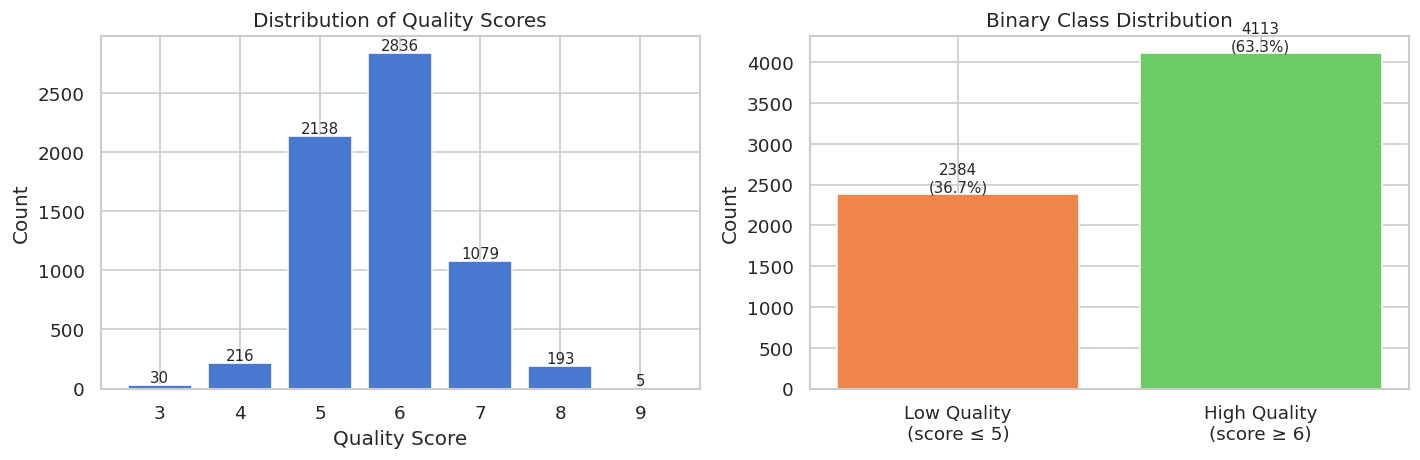

Class balance — Low: 2384 | High: 4113


In [ ]:
# Distribution of quality scores
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw quality distribution
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Quality Scores')
for i, (score, count) in enumerate(quality_counts.items()):
    axes[0].text(score, count + 20, str(count), ha='center', fontsize=9)

# Binary label distribution (after binarization)
binary_labels = (df['quality'] >= 6).astype(int)
label_counts = binary_labels.value_counts().sort_index()
axes[1].bar(['Low Quality\n(score ≤ 5)', 'High Quality\n(score ≥ 6)'],
            label_counts.values,
            color=sns.color_palette('muted')[1:3], edgecolor='white')
axes[1].set_ylabel('Count')
axes[1].set_title('Binary Class Distribution')
for i, count in enumerate(label_counts.values):
    axes[1].text(i, count + 30, f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('quality_distribution.png', bbox_inches='tight')
plt.show()
print(f'Class balance — Low: {label_counts[0]} | High: {label_counts[1]}')

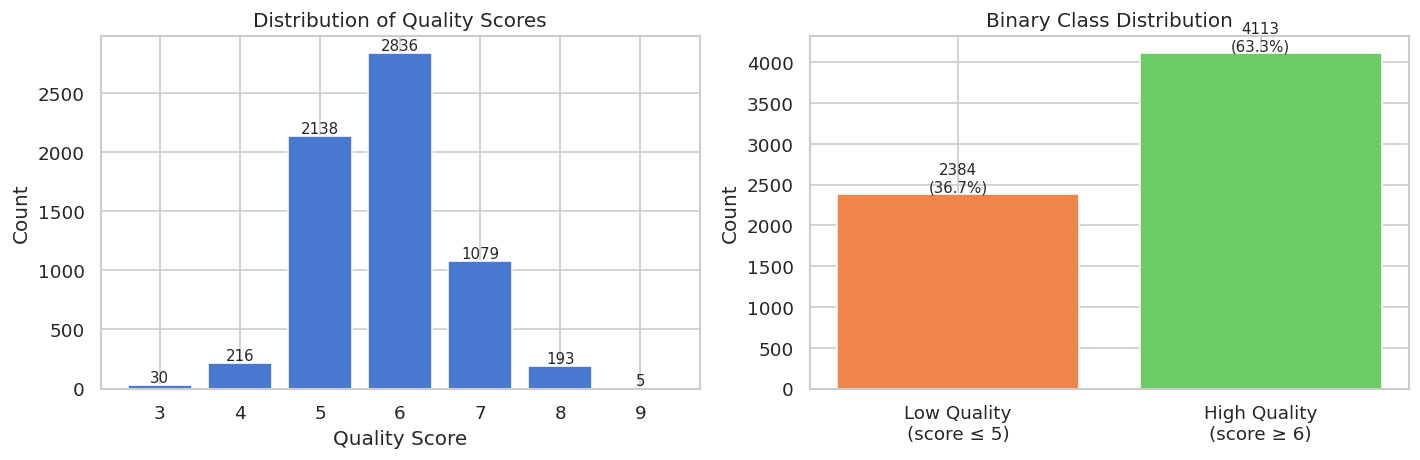

Class balance — Low: 2384 | High: 4113


In [ ]:
# Understanding how quality scores are distributed tells us whether the dataset is balanced
# and informs our decision about how to frame the prediction task
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left plot: raw quality score distribution
# Most wines score 5 or 6 -- extreme scores (3, 4, 8, 9) are rare
quality_counts = df['quality'].value_counts().sort_index()
axes[0].bar(quality_counts.index, quality_counts.values, color=sns.color_palette('muted')[0], edgecolor='white')
axes[0].set_xlabel('Quality Score')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Quality Scores')
for i, (score, count) in enumerate(quality_counts.items()):
    axes[0].text(score, count + 20, str(count), ha='center', fontsize=9)

# Right plot: binary class distribution after applying the score >= 6 threshold
# This shows the class balance we will be working with in modeling
binary_labels = (df['quality'] >= 6).astype(int)
label_counts = binary_labels.value_counts().sort_index()
axes[1].bar(['Low Quality\n(score ≤ 5)', 'High Quality\n(score ≥ 6)'],
            label_counts.values,
            color=sns.color_palette('muted')[1:3], edgecolor='white')
axes[1].set_ylabel('Count')
axes[1].set_title('Binary Class Distribution')
for i, count in enumerate(label_counts.values):
    axes[1].text(i, count + 30, f'{count}\n({count/len(df)*100:.1f}%)', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('quality_distribution.png', bbox_inches='tight')
plt.show()
print(f'Class balance — Low: {label_counts[0]} | High: {label_counts[1]}')

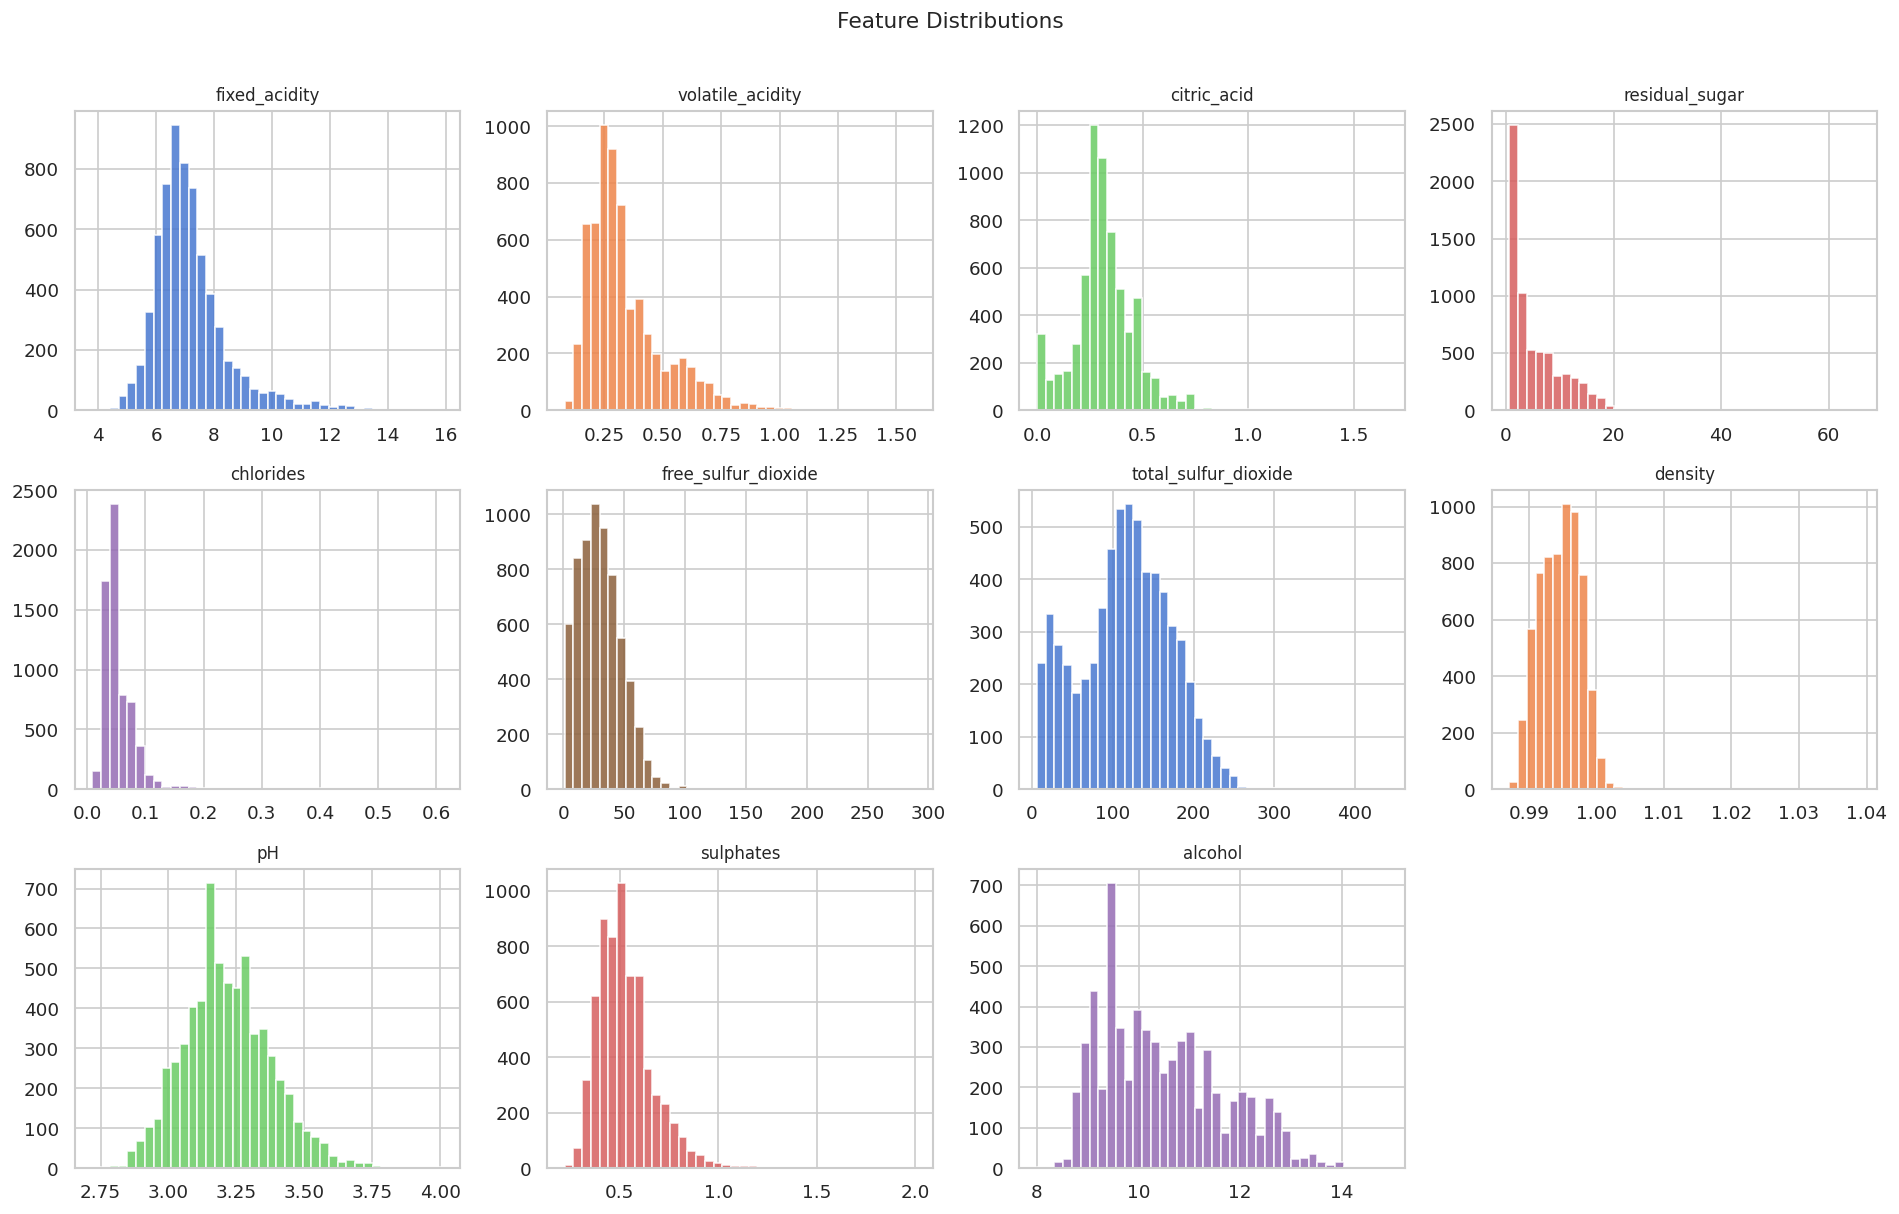

In [ ]:
# Create a Histogram for all 11 features
# using this it becomes easier to find skewd distrubtions and outliers
feature_cols = X.columns.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten() # flatten the array so we can index with a single number

for i, col in enumerate(feature_cols):
    axes[i].hist(df[col], bins=40, color=sns.color_palette('muted')[i % 6], edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('')

# The 12th subplot has no data so it is hidden
axes[-1].set_visible(False)

plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('feature_distributions.png', bbox_inches='tight')
plt.show()

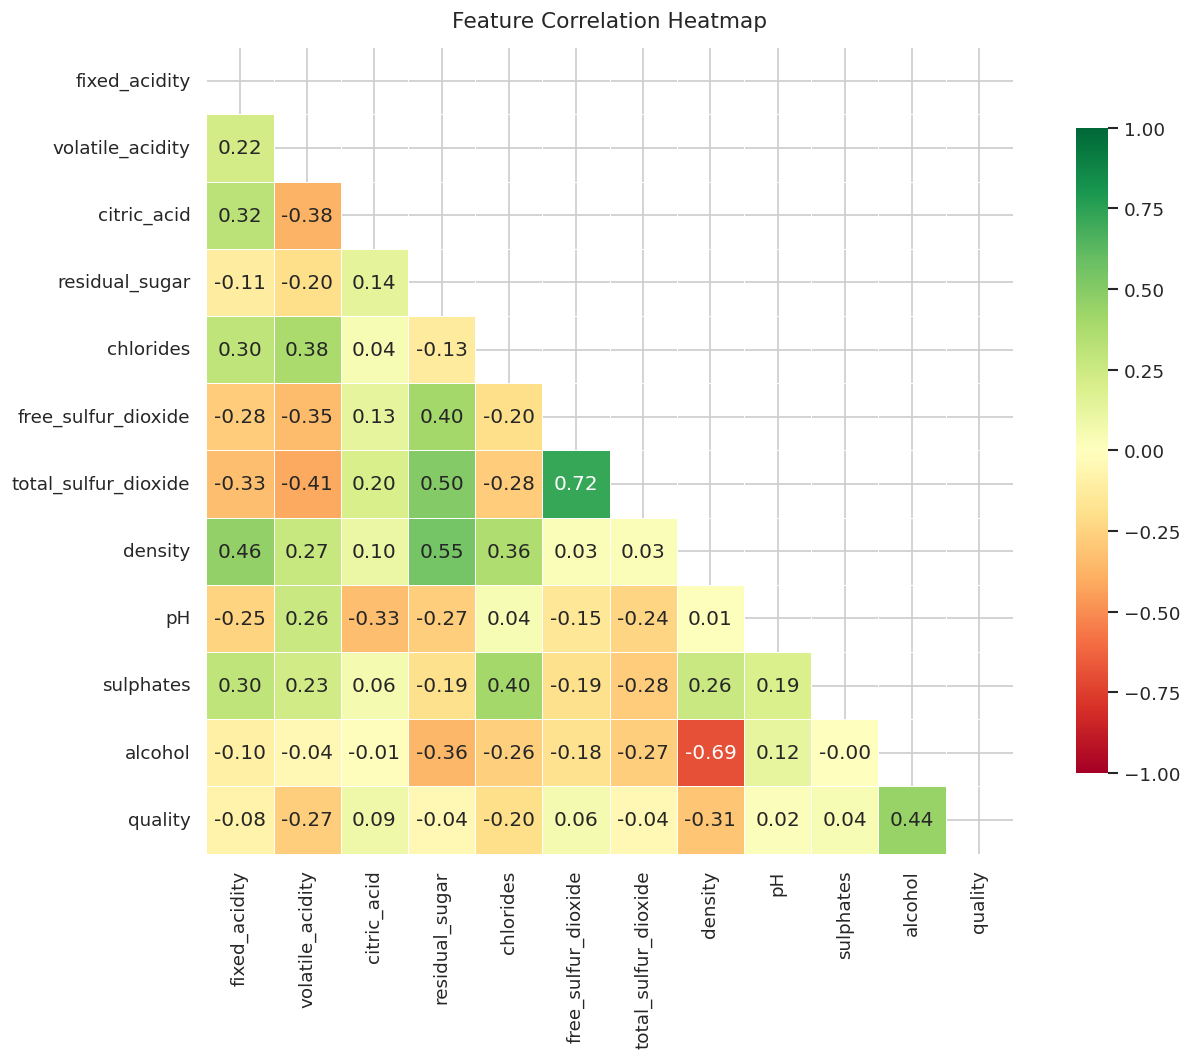

Top correlations with quality score:
alcohol                 0.44
density                -0.31
volatile_acidity       -0.27
chlorides              -0.20
citric_acid             0.09
fixed_acidity          -0.08
free_sulfur_dioxide     0.06
total_sulfur_dioxide   -0.04
residual_sugar         -0.04
sulphates               0.04
pH                      0.02


In [ ]:
# Create a correlation heatmap to find how strongly a pair of vairables move with eachother
plt.figure(figsize=(12, 9))
corr = df.corr(numeric_only=True).round(2)

#mask the upper triangle to hide duplicate information
mask = np.triu(np.ones_like(corr, dtype=bool))  # Show lower triangle only

sns.heatmap(
    corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Heatmap', fontsize=13, pad=12)
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

# Print which features correlate the most with qaulity
print('Top correlations with quality score:')
print(corr['quality'].drop('quality').sort_values(key=abs, ascending=False).to_string())

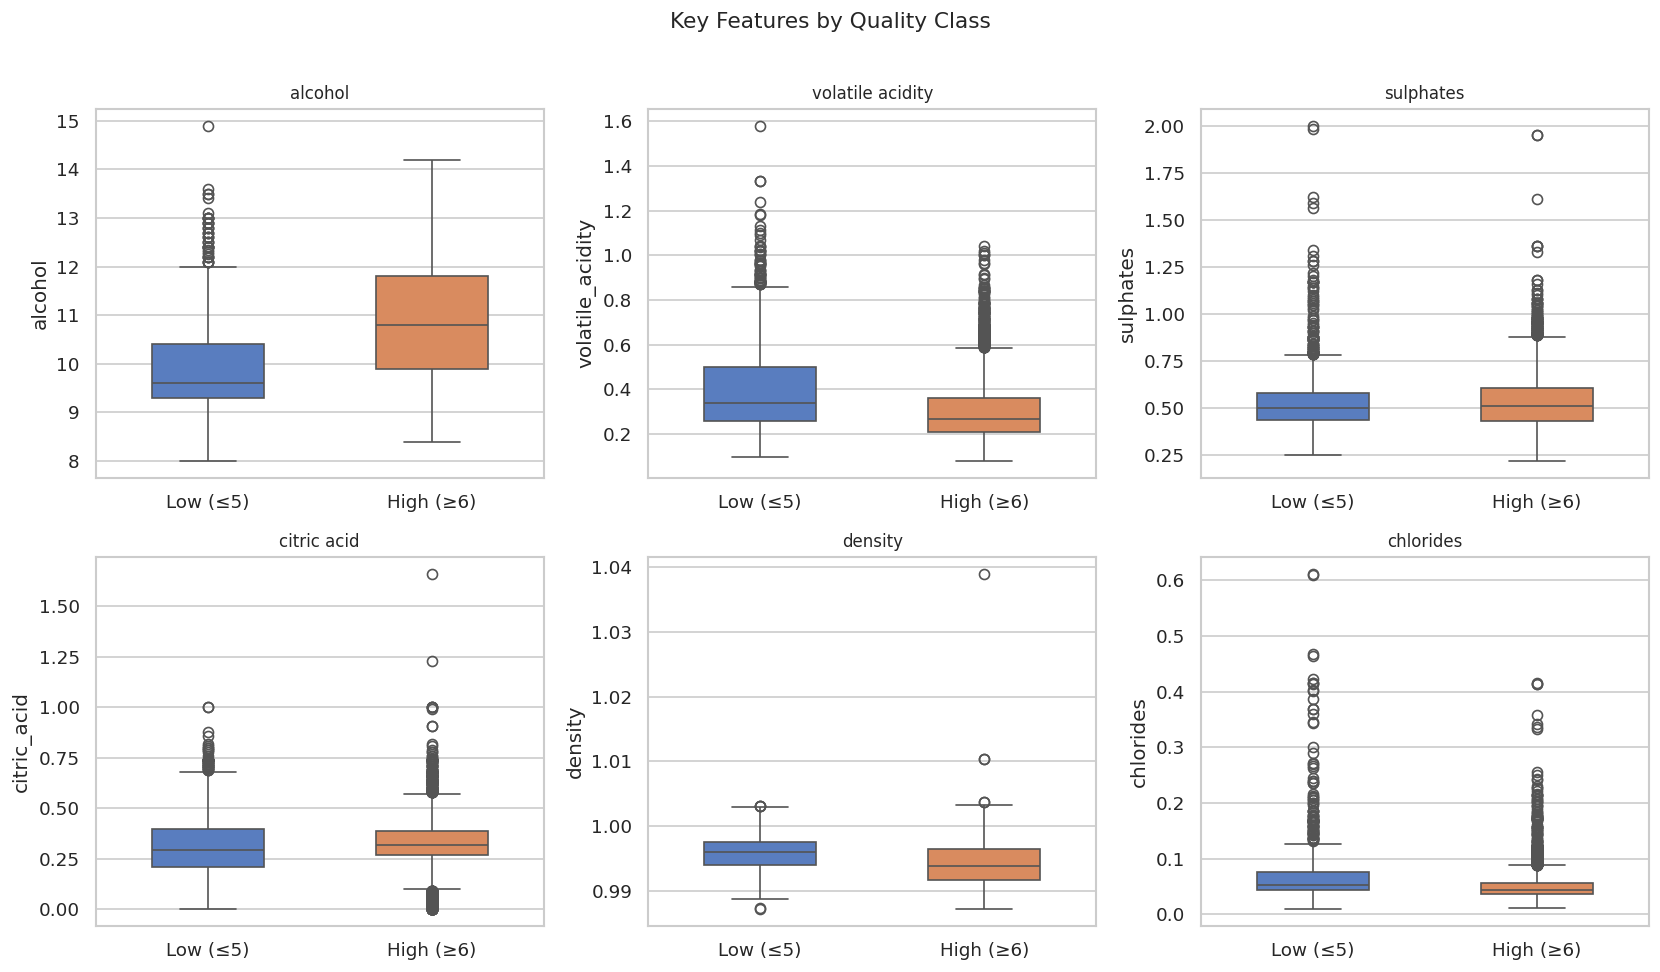

In [ ]:
# Create a boxplot to cmompare features easier
df_plot = df.copy()
df_plot['quality_label'] = df_plot['quality'].apply(lambda x: 'High (≥6)' if x >= 6 else 'Low (≤5)')

# Rename columns to remove spaces (fixes seaborn compatibility)
df_plot.columns = [c.replace(' ', '_') for c in df_plot.columns]

# Focus the features that had the strongest correlation with quality in the heatmap
top_features = ['alcohol', 'volatile_acidity', 'sulphates', 'citric_acid', 'density', 'chlorides']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(top_features):
    sns.boxplot(
        data=df_plot, x='quality_label', y=col,
        palette='muted', ax=axes[i], width=0.5
    )
    axes[i].set_title(col.replace('_', ' '), fontsize=10)
    axes[i].set_xlabel('')

plt.suptitle('Key Features by Quality Class', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('boxplots_by_class.png', bbox_inches='tight')
plt.show()

## 3. Preprocessing

In [ ]:
# Convert raw scores into binary classifcation
# High quality = score >= 6  label 1
# Low quality =  score <= 5  label 0
y_binary = (y.values.ravel() >= 6).astype(int)

print(f'Class distribution:')
print(f'  Low quality  (0): {(y_binary == 0).sum()} samples ({(y_binary == 0).mean()*100:.1f}%)')
print(f'  High quality (1): {(y_binary == 1).sum()} samples ({(y_binary == 1).mean()*100:.1f}%)')


X_features = X.copy()
print(f'\nFeatures shape: {X_features.shape}')
print(f'Missing values: {X_features.isnull().sum().sum()}')

Class distribution:
  Low quality  (0): 2384 samples (36.7%)
  High quality (1): 4113 samples (63.3%)

Features shape: (6497, 11)
Missing values: 0


In [ ]:
# Split data into training 80% and test 20%
#random_state = 42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X_features, y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print(f'Training set:   {X_train.shape[0]} samples')
print(f'Test set:       {X_test.shape[0]} samples')
# Confirm class balance after split
print(f'Train class 1%: {y_train.mean()*100:.1f}%')
print(f'Test  class 1%: {y_test.mean()*100:.1f}%')

Training set:   5197 samples
Test set:       1300 samples
Train class 1%: 63.3%
Test  class 1%: 63.3%


In [ ]:
#Standardize features to prvent leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Features scaled using StandardScaler (mean=0, std=1).')
print(f'Train mean (post-scale): {X_train_scaled.mean():.4f}')
print(f'Train std  (post-scale): {X_train_scaled.std():.4f}')

Features scaled using StandardScaler (mean=0, std=1).
Train mean (post-scale): -0.0000
Train std  (post-scale): 1.0000


## 4. Model Training

In [ ]:
#Logistic Regression is our linear baseline
#If ensmble performs better then non linear patterns are important
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

lr_cv = cross_val_score(lr, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Logistic Regression — 5-fold CV Accuracy: {lr_cv.mean():.4f} ± {lr_cv.std():.4f}')

Logistic Regression — 5-fold CV Accuracy: 0.7414 ± 0.0035


In [ ]:
#Random Forest is good for non linear interactions
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_cv = cross_val_score(rf, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Random Forest — 5-fold CV Accuracy: {rf_cv.mean():.4f} ± {rf_cv.std():.4f}')

Random Forest — 5-fold CV Accuracy: 0.8189 ± 0.0127


In [ ]:
#Graident boosting has each tree correct the errors of the last one
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
gb.fit(X_train_scaled, y_train)

gb_cv = cross_val_score(gb, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Gradient Boosting — 5-fold CV Accuracy: {gb_cv.mean():.4f} ± {gb_cv.std():.4f}')

Gradient Boosting — 5-fold CV Accuracy: 0.7893 ± 0.0072


In [ ]:
# Perform tunning on random forest at it performed best.
from sklearn.model_selection import GridSearchCV

#use GridSearchCV to try all possible combinations
param_grid = {
    'n_estimators':     [100, 200, 300],
    'max_depth':        [10, 20, None],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

#print winning combination and its cross validate accuracy
print(f'Best parameters:  {grid_search.best_params_}')
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

# Find best model to use for all downstream evaluation cells
rf_tuned = grid_search.best_estimator_
tuned_cv = cross_val_score(rf_tuned, X_train_scaled, y_train, cv=5, scoring='accuracy')
print(f'Tuned RF — 5-fold CV Accuracy: {tuned_cv.mean():.4f} ± {tuned_cv.std():.4f}')

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Best parameters:  {'max_depth': 20, 'min_samples_leaf': 1, 'n_estimators': 300}
Best CV accuracy: 0.8203
Tuned RF — 5-fold CV Accuracy: 0.8203 ± 0.0103


## 5. Evaluation

In [ ]:
#Compare all models on the held-out test set
# CV Mean is included to check for overfitting
models = {
    'Logistic Regression':   lr,
    'Random Forest':         rf,
    'Random Forest (tuned)': rf_tuned,
    'Gradient Boosting':     gb
}

results = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    results.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'ROC-AUC':  round(roc_auc_score(y_test, y_prob), 4),
        'CV Mean':  round(cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean(), 4)
    })
# build a summary table
results_df = pd.DataFrame(results).set_index('Model')
print('=== Model Comparison (Test Set) ===')
print(results_df.to_string())

=== Model Comparison (Test Set) ===
                       Accuracy  ROC-AUC  CV Mean
Model                                            
Logistic Regression      0.7338   0.8045   0.7414
Random Forest            0.8431   0.9055   0.8189
Random Forest (tuned)    0.8438   0.9045   0.8203
Gradient Boosting        0.8062   0.8679   0.7893


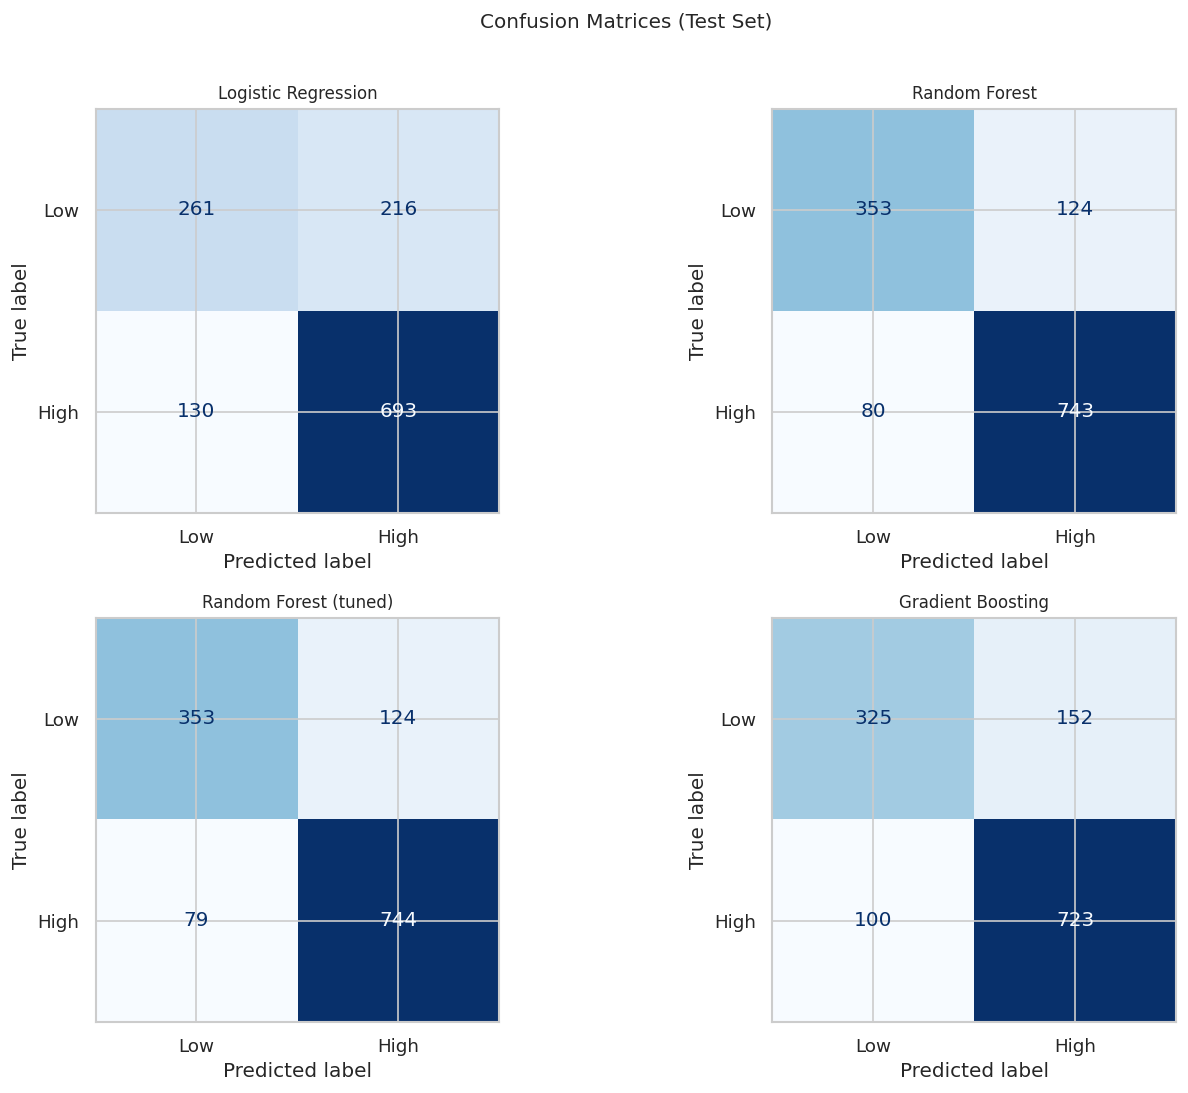

In [ ]:
# --- Confusion matrices for all models ---
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Low', 'High'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10)

plt.suptitle('Confusion Matrices (Test Set)', fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

In [ ]:
# --- Detailed classification reports ---
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, target_names=['Low Quality', 'High Quality']))


=== Logistic Regression ===
              precision    recall  f1-score   support

 Low Quality       0.67      0.55      0.60       477
High Quality       0.76      0.84      0.80       823

    accuracy                           0.73      1300
   macro avg       0.71      0.69      0.70      1300
weighted avg       0.73      0.73      0.73      1300


=== Random Forest ===
              precision    recall  f1-score   support

 Low Quality       0.82      0.74      0.78       477
High Quality       0.86      0.90      0.88       823

    accuracy                           0.84      1300
   macro avg       0.84      0.82      0.83      1300
weighted avg       0.84      0.84      0.84      1300


=== Random Forest (tuned) ===
              precision    recall  f1-score   support

 Low Quality       0.82      0.74      0.78       477
High Quality       0.86      0.90      0.88       823

    accuracy                           0.84      1300
   macro avg       0.84      0.82      0.83  

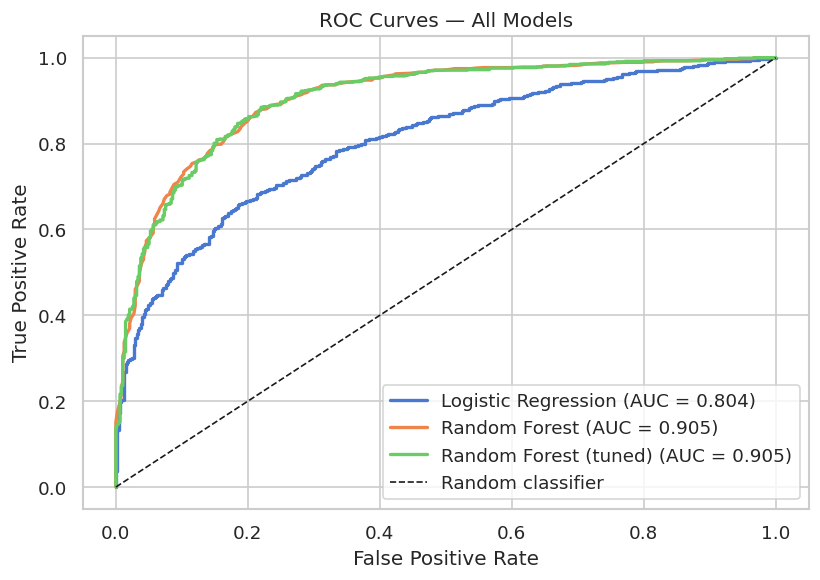

In [ ]:
# --- ROC Curves ---
plt.figure(figsize=(7, 5))

colors = sns.color_palette('muted', 3)
for (name, model), color in zip(models.items(), colors):
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Models')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

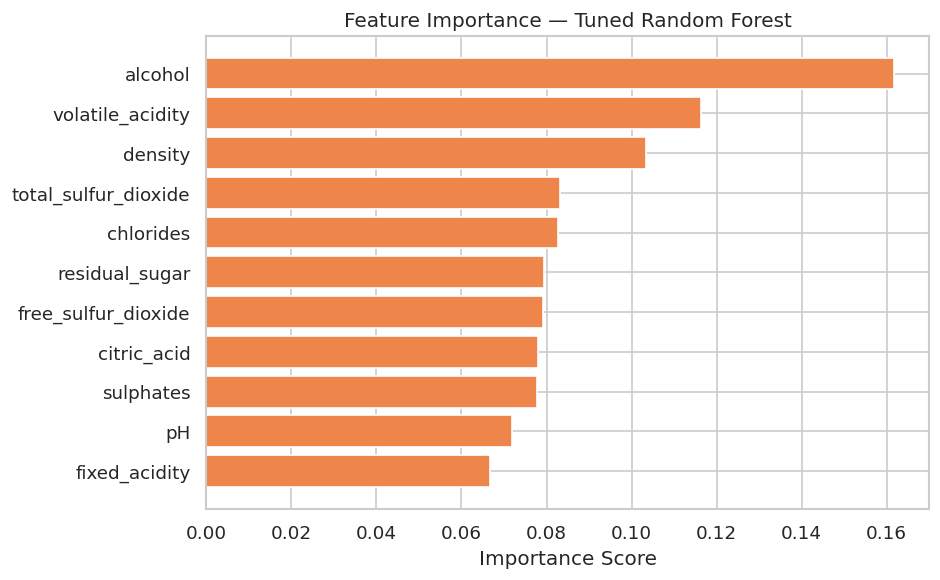


Top 5 most important features:
             Feature  Importance
             alcohol    0.161808
    volatile_acidity    0.116227
             density    0.103384
total_sulfur_dioxide    0.083233
           chlorides    0.082663


In [ ]:
# --- Feature Importance (Tuned Random Forest) ---
importances = rf_tuned.feature_importances_
feat_names = X_features.columns.tolist()
feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feat_df['Feature'], feat_df['Importance'],
         color=sns.color_palette('muted')[1], edgecolor='white')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Tuned Random Forest')
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 5 most important features:')
print(feat_df.sort_values('Importance', ascending=False).head(5).to_string(index=False))

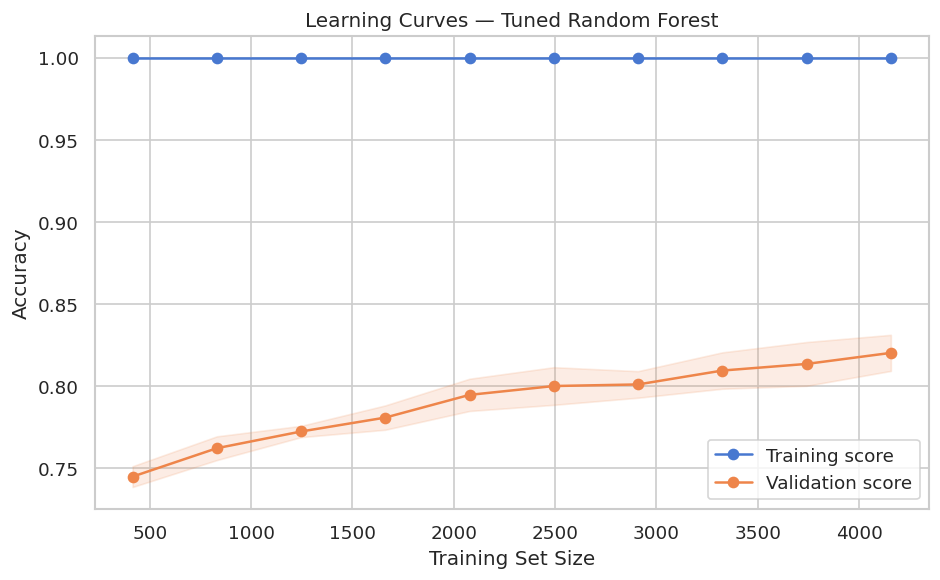

In [ ]:
# --- Learning Curves (Tuned Random Forest — best model) ---
train_sizes, train_scores, val_scores = learning_curve(
    rf_tuned, X_train_scaled, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5, scoring='accuracy', n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color=sns.color_palette('muted')[0], label='Training score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=sns.color_palette('muted')[0])
plt.plot(train_sizes, val_mean, 'o-', color=sns.color_palette('muted')[1], label='Validation score')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=sns.color_palette('muted')[1])
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curves — Tuned Random Forest')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('learning_curves.png', bbox_inches='tight')
plt.show()

## 6. Results Summary & Discussion

In [ ]:
# --- Final model comparison table ---
print('=' * 55)
print('FINAL MODEL COMPARISON — TEST SET')
print('=' * 55)
print(results_df.to_string())
print('=' * 55)

best_model = results_df['Accuracy'].idxmax()
print(f'\nBest model by accuracy: {best_model}')

FINAL MODEL COMPARISON — TEST SET
                       Accuracy  ROC-AUC  CV Mean
Model                                            
Logistic Regression      0.7338   0.8045   0.7414
Random Forest            0.8431   0.9055   0.8189
Random Forest (tuned)    0.8438   0.9045   0.8203
Gradient Boosting        0.8062   0.8679   0.7893

Best model by accuracy: Random Forest (tuned)


## 7. Interpretation & Future Work

### Key Findings
- **Alcohol content** and **volatile acidity** are the strongest predictors of wine quality, consistent with domain knowledge.
- Random Forest and Gradient Boosting outperform the Logistic Regression baseline, suggesting non-linear relationships between features and quality.
- The binary classification framing (≥6 = high, ≤5 = low) yields a reasonable class balance and makes the problem tractable.

### Limitations
- The quality labels are based on expert sensory evaluation — subjective assessments introduce label noise.
- The dataset does not include wine type (red vs. white) as a feature; training separate models per type may improve performance.
- Scores of 3, 4, 8, and 9 are rare — the model may struggle at quality extremes.
- No information on grape variety, vintage, or price is available.

### Future Improvements
- **Hyperparameter tuning**: Use `GridSearchCV` or `RandomizedSearchCV` on Random Forest / Gradient Boosting.
- **Class imbalance handling**: Apply SMOTE or class-weight adjustments to improve minority-class recall.
- **Feature engineering**: Create interaction terms (e.g., alcohol × sulphates) or apply PCA for dimensionality reduction.
- **Multi-class approach**: Predict exact quality score (3–9) using ordinal regression or multi-class classifiers.
- **Separate models**: Train and compare dedicated red and white wine models.
- **Deployment**: Wrap the best model in a Flask/FastAPI endpoint or a Streamlit app for real-time predictions.